In [1]:
import geopandas as gpd
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')


In [2]:
notebook_dir   = Path.cwd()
ruta_shapefile = notebook_dir / 'Comunas' / 'comunas.shp'
ruta_resumen   = notebook_dir / 'resumen_hacinamiento_comunas.csv'


In [3]:
resumen = pd.read_csv(ruta_resumen)

resumen.head()
comunas = gpd.read_file(ruta_shapefile)
los_rios = comunas[comunas['codregion'] == 14].copy()
los_rios = los_rios.reset_index(drop=True)


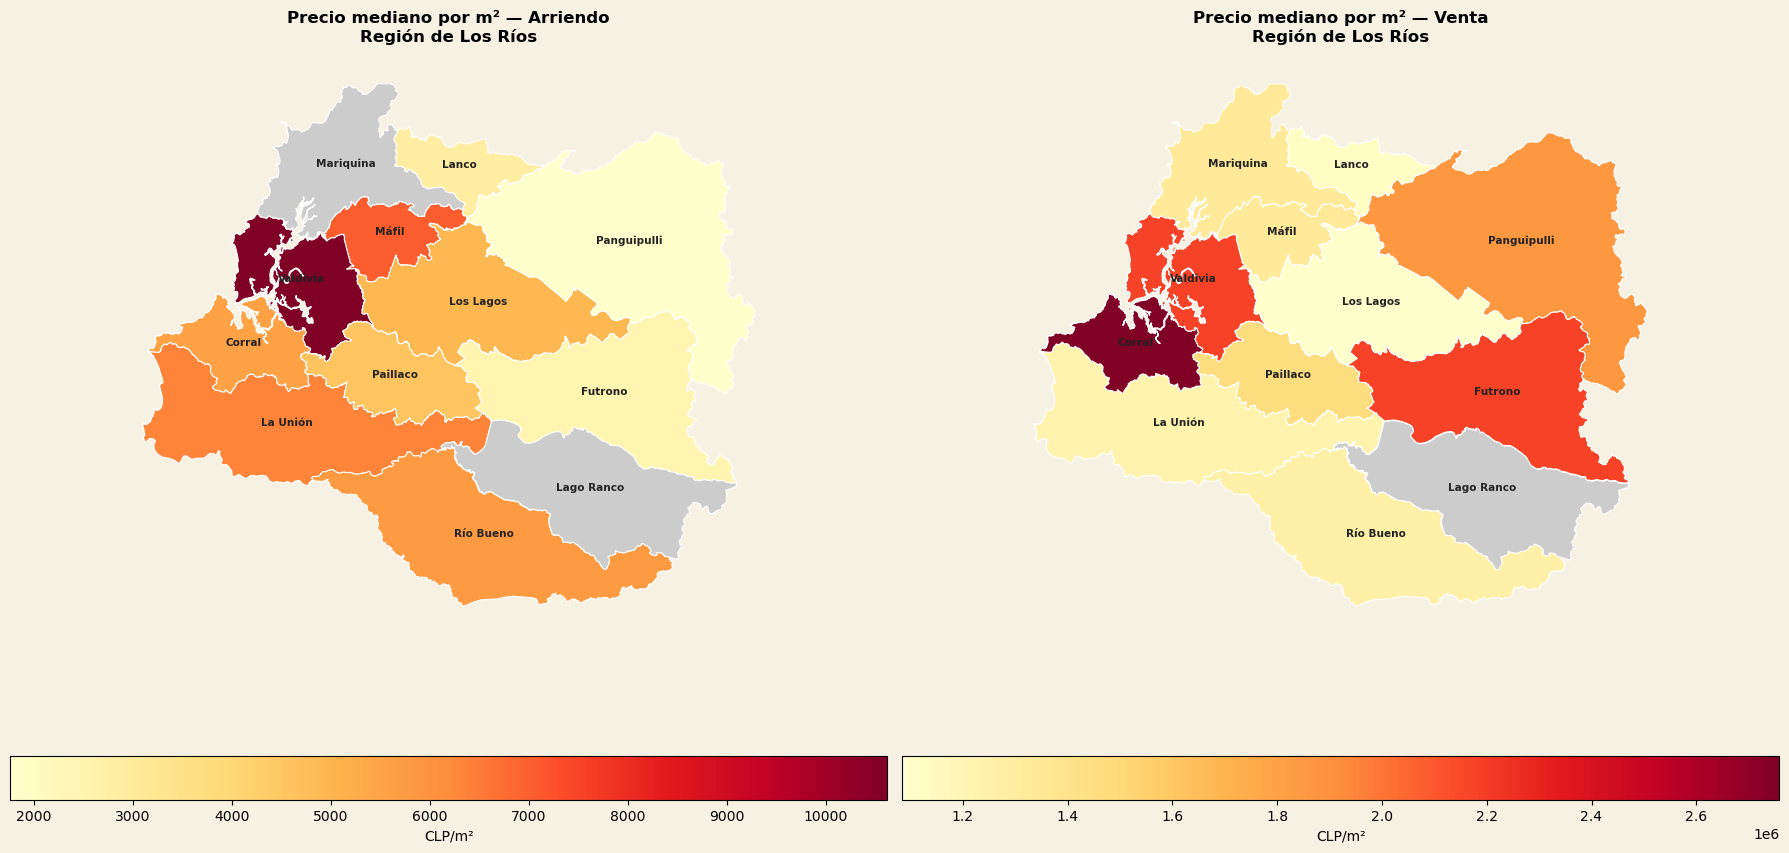

In [4]:
# datos por modalidad
precio_arr = resumen[resumen['modalidad'] == 'arriendo'][['comuna', 'precio_m2_mediana', 'n_propiedades']]
precio_ven = resumen[resumen['modalidad'] == 'venta'][['comuna', 'precio_m2_mediana', 'n_propiedades']]


# unir dataframe con shapefile
gdf_arr_p = los_rios.merge(precio_arr, left_on='Comuna', right_on='comuna', how='left')
gdf_ven_p = los_rios.merge(precio_ven, left_on='Comuna', right_on='comuna', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor='#f7f1e3')

# Mapa arriendo
ax = axes[0]
ax.set_facecolor('#e8f4f8')
# hacer escalas de arriendo min y max
vmin_arr = precio_arr['precio_m2_mediana'].min()
vmax_arr = precio_arr['precio_m2_mediana'].max()

sin = gdf_arr_p[gdf_arr_p['precio_m2_mediana'].isna()]['Comuna'].tolist()
# pintar
gdf_arr_p.plot(
    column       = 'precio_m2_mediana',
    cmap         = 'YlOrRd', # escala azul bajo - rojo alto es 'RdBu_r' 
    vmin         = vmin_arr,
    vmax         = vmax_arr,
    legend       = True,
    missing_kwds = {'color': '#cccccc', 'label': 'Sin datos'},
    ax           = ax,
    edgecolor    = 'white',
    linewidth    = 0.8,
    legend_kwds  = {'label': 'CLP/m²', 'orientation': 'horizontal'},
)
#nombrar
for _, row in gdf_arr_p.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text       = row['Comuna'],
        xy         = (centroid.x, centroid.y),
        ha         = 'center',
        fontsize   = 7.5,
        fontweight = 'bold',
        color      = '#222222',
    )
ax.set_title('Precio mediano por m² — Arriendo\nRegión de Los Ríos', fontsize=12, fontweight='bold', pad=12)
ax.grid(True, alpha=0.3)
ax.set_axis_off()

# Mapa venta
ax = axes[1]
ax.set_facecolor('#e8f4f8')

# hacer escalas de venta el max y min
vmin_ven = precio_ven['precio_m2_mediana'].min()
vmax_ven = precio_ven['precio_m2_mediana'].max()

sin = gdf_ven_p[gdf_ven_p['precio_m2_mediana'].isna()]['Comuna'].tolist()

# pintar
gdf_ven_p.plot(
    column       = 'precio_m2_mediana',
    cmap         = 'YlOrRd',
    vmin         = vmin_ven,
    vmax         = vmax_ven,
    legend       = True,
    missing_kwds = {'color': '#cccccc', 'label': 'Sin datos'},
    ax           = ax,
    edgecolor    = 'white',
    linewidth    = 0.8,
    legend_kwds  = {'label': 'CLP/m²', 'orientation': 'horizontal'},
)
# nombrar
for _, row in gdf_ven_p.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text       = row['Comuna'],
        xy         = (centroid.x, centroid.y),
        ha         = 'center',
        fontsize   = 7.5,
        fontweight = 'bold',
        color      = '#222222',
    )
ax.set_title('Precio mediano por m² — Venta\nRegión de Los Ríos', fontsize=12, fontweight='bold', pad=12)
ax.grid(True, alpha=0.3)
ax.set_axis_off()

plt.tight_layout()
plt.show()



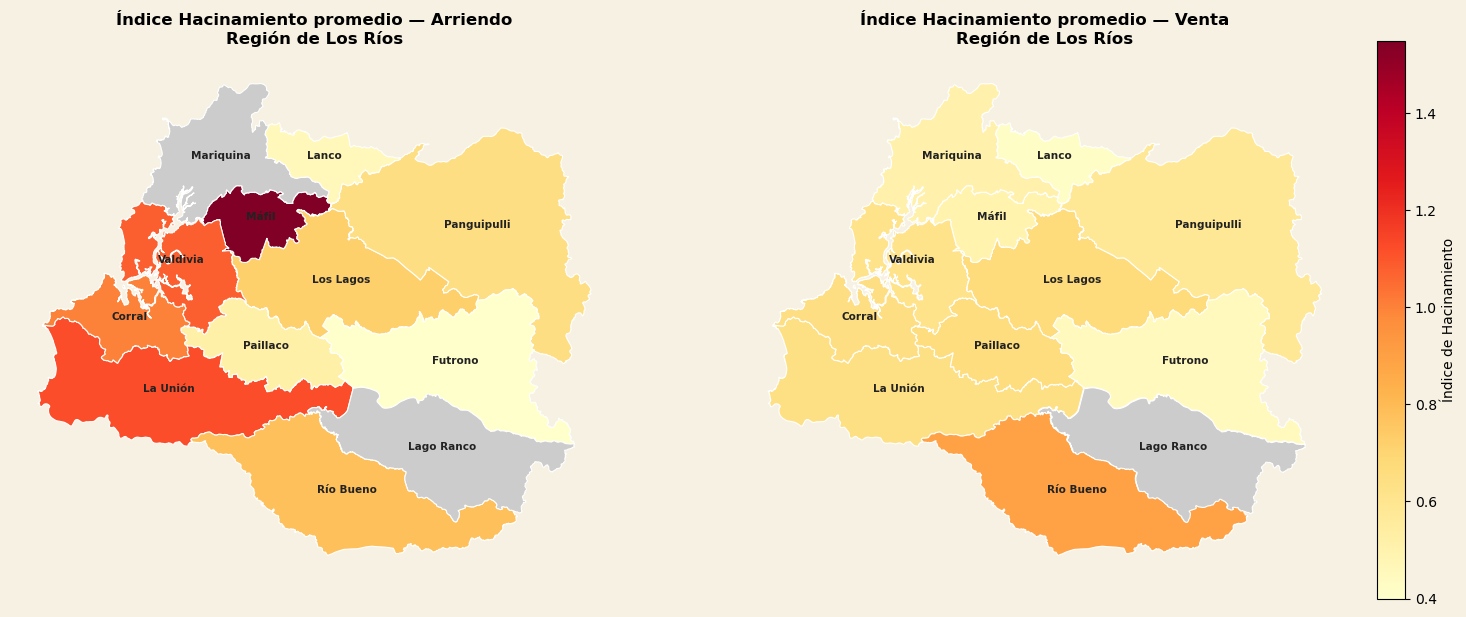

In [5]:
# Preparar datos por modalidad
hacin_arr = resumen[resumen['modalidad'] == 'arriendo'][['comuna', 'indice_promedio', 'n_propiedades']]
hacin_ven = resumen[resumen['modalidad'] == 'venta'][['comuna', 'indice_promedio', 'n_propiedades']]

gdf_arr_h = los_rios.merge(hacin_arr, left_on='Comuna', right_on='comuna', how='left')
gdf_ven_h = los_rios.merge(hacin_ven, left_on='Comuna', right_on='comuna', how='left')

# Escala compartida entre ambos mapas
vmin = resumen['indice_promedio'].min()
vmax = resumen['indice_promedio'].max()

fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor='#f7f1e3')

for ax, gdf_mod, titulo in zip(
    axes,
    [gdf_arr_h, gdf_ven_h],
    ['Arriendo', 'Venta']
):
    ax.set_facecolor('#e8f4f8')

    sin = gdf_mod[gdf_mod['indice_promedio'].isna()]['Comuna'].tolist()

    gdf_mod.plot(
        column       = 'indice_promedio',
        cmap         = 'YlOrRd', 
        vmin         = vmin,
        vmax         = vmax,
        missing_kwds = {'color': '#cccccc', 'label': 'Sin datos'},
        ax           = ax,
        edgecolor    = 'white',
        linewidth    = 0.8,

    )
    

    # Etiquetas de comunas
    for _, row in gdf_mod.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            text = row['Comuna'],
            xy   = (centroid.x, centroid.y),
            ha   = 'center',
            fontsize   = 7.5,
            fontweight = 'bold',
            color      = '#222222',
        )

    ax.set_title(
        f'Índice Hacinamiento promedio — {titulo}\nRegión de Los Ríos',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.grid(True, alpha=0.3)
    ax.set_axis_off()
import matplotlib.cm as cm
import matplotlib.colors as mcolors

sm = cm.ScalarMappable(cmap='YlOrRd', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Índice de Hacinamiento', fontsize=10)
